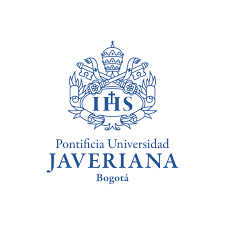
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

**Autor**: Juan Camilo Torres Meza

**Fecha de Inicio**: 16 de Abril del 2026

**Fecha actual**: 16 de Abril del 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [1]:
### Importación de bibliotecas básicas
import os                           #---Interactuar con el sistema operativo (gestionar archivos)
import sys                          #---usar recursos del sistema
sys.path.append('/usr/lib/python3/dist-packages/')        #---ruta para que python encuentre los paquetes instalados
import pandas as pd                 #---graficar y objetos dataframe
import numpy as np                  #---Algebra matricial
import matplotlib.pyplot as plt     #---Formatos de graficas
import seaborn as sns               #---Estadistica y graficar
from pylab import *                 #---Importa funciones de graficación y matemáticas de forma global

In [2]:
###Importación de Bibliotecas Especializadas
import findspark
findspark.init()                                #---Localizador de Spark en el entorno general
from pyspark.sql import functions as F          #---Se importan funciones y se nombran como F
from pyspark import SparkContext, SparkConf     #---Contexto y configuración de PySpark
from pyspark.sql import SparkSession            #---Sesión para entorno de consultas sobre SQL
from pyspark.sql import SQLContext              #---Contexto para trabajar con consultas SQL en Spark
from pyspark.sql.types import *                 #---Tipos de datos de Spark SQL
from pyspark.sql.functions import *             #---Importa todas las funciones de PySpark SQL para manipulación de datos

## Levantar sesión SPARK

In [3]:
### Se requiere levantar la sesión para Trabajar con los Servicios
### Basados en SPARK: Procesamiento Paralelo y Distribuido sobre Grandes Volumenes de Datos
configura = SparkConf()
configura.setAppName("Calidad_Agua_Torres")               #--- Nombre de la aplicación
configura.set("spark.scheduler.mode","FAIR")        #---Configuracion de tipo "FAIR" para que sea justo y equitativo. 
                                                    #---Se requiere que multiples usuarios tengan recursos concurrentemente
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")   #---Ubicación xml de la configuración FAIR
configura.setMaster("spark://10.43.97.207:7077")    #---Se configura en la dirección del MASTER
sparkS = SparkSession.builder.config(conf=configura).getOrCreate()    #---Se crea la sesión
SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)
sparkContextoS = sparkS.sparkContext.getOrCreate()
print("Sesión creada: Parcial ProcesamientoDatos")
sparkS

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 10:40:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión creada: Parcial ProcesamientoDatos


## **2.- Carga de Datos desde el HADOOP HDFS**

In [4]:
#Se lee el archivo "waterquality.csv" que se encuentra en el directorio actual
df00 = sparkS.read.format("csv").option("header","true").load("waterquality.csv")
df00.show(5) # Se muestran las 5 primeras filas para verificar la carga 

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [5]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

In [6]:
## Copio y cambio los nombres de las columnas

NomOriginal=['STATION CODE','LOCATIONS','STATE','TEMP','DO','pH','CONDUCTIVITY','BOD','NITRATE_N_NITRITE_N','FECAL_COLIFORM','TOTAL_COLIFORM']
NomNueva=['CODE','LOCATIONS','STATE','TEMP','OXYGEN','PH','CONDUCTIVITY','GERM','NITROGEN','EXCRETION','COLIFORM']

#### Version
### original --> nueva
df01 = df00 #Copiamos dataframe original para no afectar df00 
### Se hará un comprimido para el cambio en un bucle
for antes, nuevo in zip(df01.columns, NomNueva):       #---En el bucle recorremos las columnas anteriores de dfPy01
    df01 = df01.withColumnRenamed(antes, nuevo)      #---Y asignamos en las columnas los nuevos nombres

#Verificamos que los nuevos nombres se aplicaron correctamente
df01.columns

['CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'OXYGEN',
 'PH',
 'CONDUCTIVITY',
 'GERM',
 'NITROGEN',
 'EXCRETION',
 'COLIFORM']

In [7]:
df01.show(5)   #---Verificamos el cambio

[Stage 2:>                                                          (0 + 1) / 1]

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+--------+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|COLIFORM|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+--------+
|1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|   6.4|8.1|         735| 3.4|       2|        3|      73|
|2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|     6|  8|         270| 3.1|       2|       72|     182|
|2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|   5.5|7.8|         355| 4.2|       9|       59|     133|
|2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|   5.5|7.8|         371| 5.6|    3.55|       90|     283|
|2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|   5.7|7.9|         294| 3.2|    2.69|       45|     132|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+--------+
only showing top 5 rows



- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

In [8]:
#Recorremos cada columna del DataFrame nuevo y las describimos
for valor in df01.columns:
    df01.describe([valor]).show()

26/04/28 10:41:07 WARN TaskSetManager: Lost task 0.0 in stage 3.0 (TID 3) (10.43.97.179 executor 1): org.apache.spark.SparkFileNotFoundException: File file:/home/estudiante/Parcial/waterquality.csv does not exist
It is possible the underlying files have been updated. You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.readCurrentFileNotFoundError(QueryExecutionErrors.scala:781)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.org$apache$spark$sql$execution$datasources$FileScanRDD$$anon$$readCurrentFile(FileScanRDD.scala:222)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.nextIterator(FileScanRDD.scala:282)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:131)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at org.apache.spark.sql.cataly

+-------+-----------------+
|summary|             CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+



+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|           OXYGEN|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+--------

26/04/28 10:41:14 WARN TaskSetManager: Lost task 0.0 in stage 21.0 (TID 18) (10.43.97.179 executor 1): org.apache.spark.SparkFileNotFoundException: File file:/home/estudiante/Parcial/waterquality.csv does not exist
It is possible the underlying files have been updated. You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.readCurrentFileNotFoundError(QueryExecutionErrors.scala:781)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.org$apache$spark$sql$execution$datasources$FileScanRDD$$anon$$readCurrentFile(FileScanRDD.scala:222)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.nextIterator(FileScanRDD.scala:282)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:131)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at org.apache.spark.sql.exec

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+



26/04/28 10:41:15 WARN TaskSetManager: Lost task 0.0 in stage 24.0 (TID 21) (10.43.97.179 executor 1): org.apache.spark.SparkFileNotFoundException: File file:/home/estudiante/Parcial/waterquality.csv does not exist
It is possible the underlying files have been updated. You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.readCurrentFileNotFoundError(QueryExecutionErrors.scala:781)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.org$apache$spark$sql$execution$datasources$FileScanRDD$$anon$$readCurrentFile(FileScanRDD.scala:222)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.nextIterator(FileScanRDD.scala:282)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:131)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at org.apache.spark.sql.cata

+-------+-----------------+
|summary|             GERM|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|          NITROGEN|
+-------+------------------+
|  count|               534|
|   mean|1.3785714285714301|
| stddev| 2.803947753154703|
|    min|                 0|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|        EXCRETION|
+-------+-----------------+
|  count|              534|
|   mean|7384.170353982301|
| stddev|30714.05963523712|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|          COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|                NA|


## **Visualización de los DATOS NULOS**

In [9]:
#### Cantidad de Datos Nulos o Irregulares
print(f"Cantidad total de registros {df01.count()}")
df01.select([F.count(F.when(F.isnan(c) | F.col (c).isNull(), c)).alias(c) for c in df01.columns]).show()

Cantidad total de registros 534
+----+---------+-----+----+------+---+------------+----+--------+---------+--------+
|CODE|LOCATIONS|STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|COLIFORM|
+----+---------+-----+----+------+---+------------+----+--------+---------+--------+
|   0|        0|    0|   0|     0|  0|           0|   0|       0|        0|       0|
+----+---------+-----+----+------+---+------------+----+--------+---------+--------+



### COMENTARIOS:
    - Se observa que no hay datos nulos o imposibles
    - Se procede a Graficar cada una de las dimensiones

In [10]:
# Filtramos los registros que tengan algún dato nulo en las variables numéricas
#para eliminar las filas que tengan valores en NULL

df01.createOrReplaceTempView("df01_sql")
df02 = sparkS.sql('''Select * from df01_sql where TEMP is not null and
       OXYGEN is not null and
       PH is not null and
       CONDUCTIVITY is not null and
       GERM is not null and
       NITROGEN is not null and
       EXCRETION is not null''')

In [11]:
#Se verifica la cantidad de valores nulos o imposibles
df02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

26/04/28 10:42:13 WARN TaskSetManager: Lost task 0.0 in stage 42.0 (TID 35) (10.43.97.179 executor 1): org.apache.spark.SparkFileNotFoundException: File file:/home/estudiante/Parcial/waterquality.csv does not exist
It is possible the underlying files have been updated. You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.readCurrentFileNotFoundError(QueryExecutionErrors.scala:781)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.org$apache$spark$sql$execution$datasources$FileScanRDD$$anon$$readCurrentFile(FileScanRDD.scala:222)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.nextIterator(FileScanRDD.scala:282)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:131)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at org.apache.spark.sql.cata

+----+---------+-----+----+------+---+------------+----+--------+---------+--------+
|CODE|LOCATIONS|STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|COLIFORM|
+----+---------+-----+----+------+---+------------+----+--------+---------+--------+
|   0|        0|    0|   0|     0|  0|           0|   0|       0|        0|       0|
+----+---------+-----+----+------+---+------------+----+--------+---------+--------+



Se logra observar que no hay datos nulos

### **Tratamiento de datos**

In [12]:

##Se procede a cambiar los tipos de datos a float
df01 = df01.withColumn('TEMP', df01['TEMP'].cast(FloatType()))
df01 = df01.withColumn('PH', df01['PH'].cast(FloatType()))
df01 = df01.withColumn('OXYGEN', df01['OXYGEN'].cast(FloatType()))
df01 = df01.withColumn('CONDUCTIVITY', df01['CONDUCTIVITY'].cast(FloatType()))
df01 = df01.withColumn('NITROGEN', df01['NITROGEN'].cast(FloatType()))
df01 = df01.withColumn('EXCRETION', df01['EXCRETION'].cast(FloatType()))
df01 = df01.withColumn('GERM', df01['GERM'].cast(FloatType()))
df01.dtypes


##Se elimina la columna COLIFORM
df02 = df01.drop('COLIFORM')
df02.columns

['CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'OXYGEN',
 'PH',
 'CONDUCTIVITY',
 'GERM',
 'NITROGEN',
 'EXCRETION']

In [13]:
# Vemos el esquema de los tipos de datos actuales
df02.printSchema()

root
 |-- CODE: string (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: float (nullable = true)
 |-- OXYGEN: float (nullable = true)
 |-- PH: float (nullable = true)
 |-- CONDUCTIVITY: float (nullable = true)
 |-- GERM: float (nullable = true)
 |-- NITROGEN: float (nullable = true)
 |-- EXCRETION: float (nullable = true)



## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

In [15]:
# Crea una vista temporal para df02 (datos sin nulos y con tipos correctos)
df02.createOrReplaceTempView("df02_sql")

# creamos la consulta del parametro "OXYGEN"
do_parametro = sparkS.sql("SELECT OXYGEN FROM df02_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.OXYGEN).collect()

# creamos la consulta del parametro "PH"
ph_parametro = sparkS.sql("SELECT PH FROM df02_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.PH).collect()

# creamos la consulta del parametro "CONDUCTIVITY"
co_parametro = sparkS.sql("SELECT CONDUCTIVITY FROM df02_sql")
co_parametro = co_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()

# creamos la consulta del parametro "GERM"
ge_parametro = sparkS.sql("SELECT GERM FROM df02_sql")
ge_parametro = ge_parametro.rdd.map(lambda fila: fila.GERM).collect()

# creamos la consulta del parametro "NITROGEN"
ni_parametro = sparkS.sql("SELECT NITROGEN FROM df02_sql")
ni_parametro = ni_parametro.rdd.map(lambda fila: fila.NITROGEN).collect()

# creamos la consulta del parametro "EXCRETION"
ex_parametro = sparkS.sql("SELECT EXCRETION FROM df02_sql")
ex_parametro = ex_parametro.rdd.map(lambda fila: fila.EXCRETION).collect()

### **Grafica Los parámetros para conocer sus características: DO y PH**
## Gráfico #1
## Oxigeno Disuelto con su PH

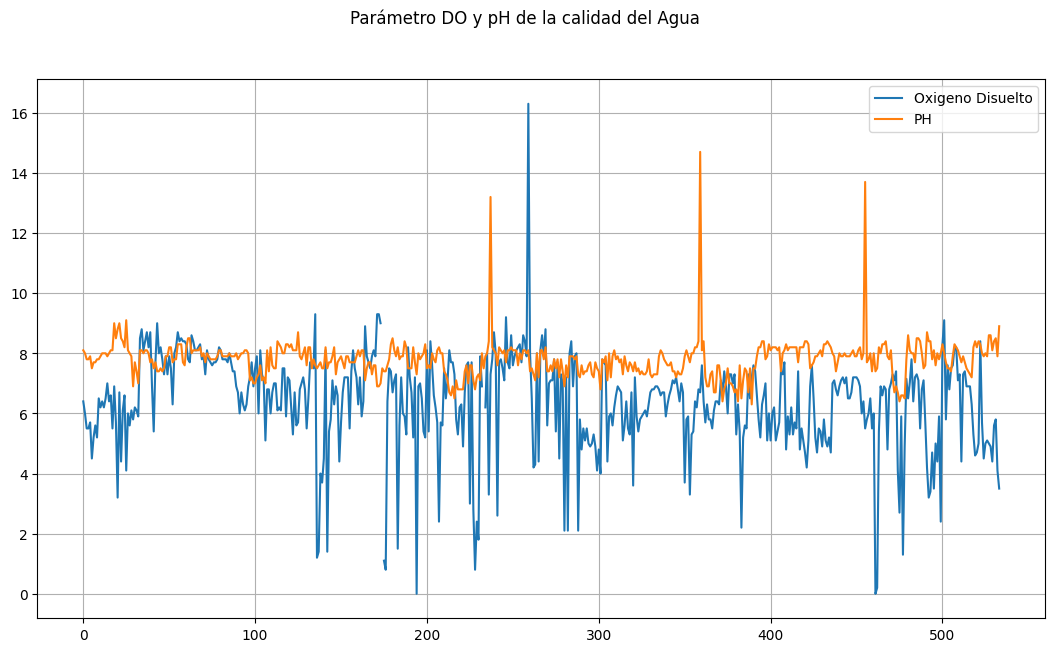

In [16]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='PH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

Se puede observar que el PH el cual se representa de color naranja se mantiene estable, manteniendose entre 7.5 y 8.5. 
Se registran picos que alcanzan valores de 13 a 14, los cuales constituyen datos atípicos o errores.
El Oxígeno Disuelto que se encuentra representado de color azul presenta variaciones entre 4 y 9 mg/L, 
con descensos puntuales. Concentraciones inferiores a 5 mg/L ya reflejan condiciones adversas para los organismos acuáticos, 
mientras que los descensos hasta 0 mg/L revelan áreas afectadas por contaminación orgánica muy intensa.

### **Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos**
## Gráfico #2
## Germenes y nivel de nitrogeno

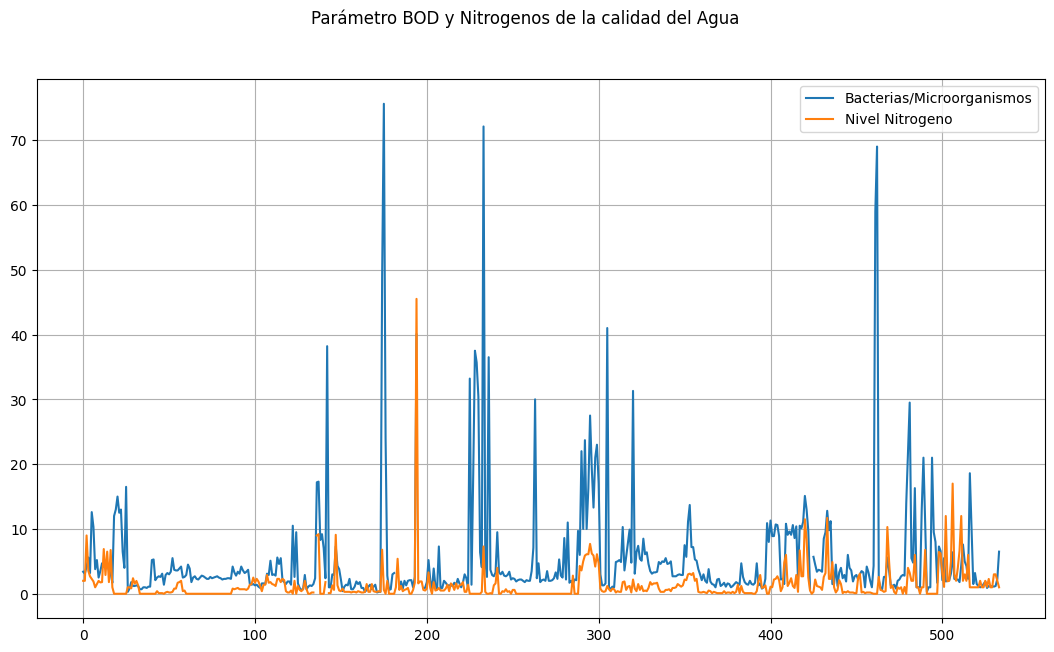

In [18]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), ge_parametro, label='Bacterias/Microorganismos')
ax1.plot(range(0,tam), ni_parametro, label='Nivel Nitrogeno')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La Demanda Biológica de Oxígeno representada por la linea azul presenta picos extremadamente pronunciados que alcanzan un valor de 75, 
reflejando episodios puntuales de contaminación orgánica severa en determinadas muestras. 
No obstante, durante la mayor parte del registro se mantiene dentro del rango de 0 a 10, nivel considerado como aceptable.

En cuanto al Nitrógeno representado por la linea naranja, muestra que sus concentraciones son generalmente reducidas,
con la excepción de un pico relevante localizado cerca de la muestra 180, donde alcanza aproximadamente 46 unidades.

### **Grafica Los parámetros para conocer sus características: FC y Conductividad**
## Gráfico #3
## Conductividad y material fecal

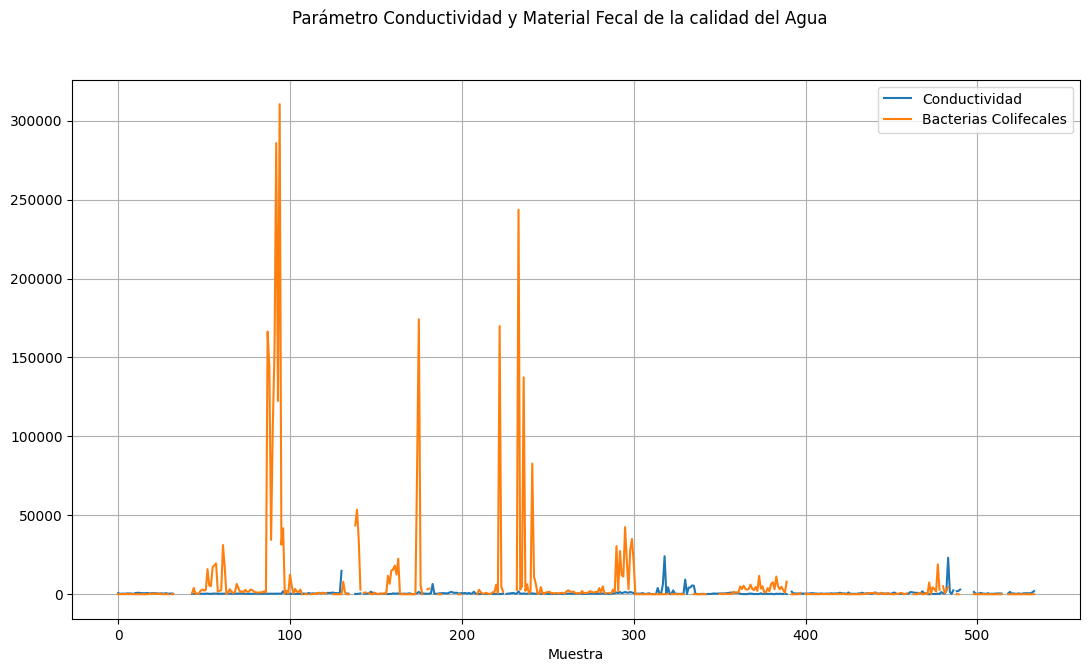

In [20]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), co_parametro, label='Conductividad')
ax1.plot(range(0,tam), ex_parametro, label='Bacterias Colifecales')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Muestra")
plt.grid()
plt.show()

Se logra observar que existen picos de coliformes de una magnitud significativa en los intervalos de las muestras 85 a 100 y 230 a 240, así como en la muestra 170, lo cual constituye un indicador crítico de contaminación fecal severa. Esta situación representa un problema grave en términos de calidad del agua.

### **Función definida por el usuario para definir el rango de calidad de agua según el pH**
 - Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

In [21]:
# El rango óptimo definido será: PH 7.0 hasta 8.5
df03 = df02.withColumn("qrPH", F.when((df02.PH>=7.0) & (df02.PH<=8.5),100).

       when(((df02.PH>=6.8) & (df02.PH<6.9)) | ((df02.PH>8.5) & (df02.PH<8.6)), 80).

       when(((df02.PH>=6.7) & (df02.PH<6.8)) | ((df02.PH>=8.6) & (df02.PH<8.8)), 60).

       when(((df02.PH>=6.5) & (df02.PH<6.7)) | ((df02.PH>=8.8) & (df02.PH<9.0)), 40).otherwise(0))

### **Función definida por el usuario para definir el rando de la calidad del agua según DO**

In [22]:
# Oxígeno disuelto, entre mayor sea el oxigeno significa que es más saludable
df03 = df03.withColumn("qrDO", F.when((df02.OXYGEN>=6.0), 100).
                      when((df02.OXYGEN>=5.1) & (df02.OXYGEN<6.0), 80).
                      when((df02.OXYGEN>=4.1) & (df02.OXYGEN<=5.0), 60).
                      when((df02.OXYGEN>=3.0) & (df02.OXYGEN<=4.0), 40).otherwise(0))

### **Función definida por el usuario para definir el rando de la calidad del agua según COND**

In [25]:
# La conductividad son las sales que están disueltas. 
# Entre menores sea el nivel de sales, mayor es la calidad
df03 = df03.withColumn("qrCOND", F.when(((df02.CONDUCTIVITY>=0.0) & (df02.CONDUCTIVITY<=75.0)), 100).
            when((df02.CONDUCTIVITY>75.0) & (df02.CONDUCTIVITY<=150.0), 80).
            when((df02.CONDUCTIVITY>150.0) & (df02.CONDUCTIVITY<=225.0), 60).
            when((df02.CONDUCTIVITY>225.0) & (df02.CONDUCTIVITY<=300.0), 40).otherwise(0))

### **Función definida por el usuario para definir el rando de la calidad del agua según BOD**

In [26]:
# GERM mide contaminación orgánica
# Entre más bajo el valor, más limpia está el agua
df03 = df03.withColumn("qrBOD", F.when(((df02.GERM>=0.0) & (df02.GERM<3.0)), 100).
                       when((df02.GERM>=3.0) & (df02.GERM<6.0), 80).
                       when((df02.GERM>=6.0) & (df02.GERM<80.0), 60).
                       when((df02.GERM>=80.0) & (df02.GERM<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura

In [27]:
# En el nitrógeno, los valores altos indican contaminación
df03 = df03.withColumn("qrNN", F.when(((df02.NITROGEN>=0.0) & (df02.NITROGEN<20.0)), 100).
                       when((df02.NITROGEN>=20.0) & (df02.NITROGEN<50.0), 80).
                       when((df02.NITROGEN>=50.0) & (df02.NITROGEN<100.0), 60).
                       when((df02.NITROGEN>=100.0) & (df02.NITROGEN<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

In [28]:
# Coliformes fecales: indicador de contaminación fecal
df03 = df03.withColumn("qrFecal", F.when(((df02.EXCRETION>=0.0) & (df02.EXCRETION<5.0)), 100).
                       when((df02.EXCRETION>=5.0) & (df02.EXCRETION<50.0), 80).
                       when((df02.EXCRETION>=50.0) & (df02.EXCRETION<500.0), 60).
                       when((df02.EXCRETION>=500.0) & (df02.EXCRETION<1000.0), 40).otherwise(0))

## **El objeto dataframe df03, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

In [29]:
#A continuación se hace una inspección en general del df02
df03.show(10)

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+
|1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|   6.4|8.1|       735.0| 3.4|     2.0|      3.0| 100| 100|     0|   80| 100|    100|
|2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|   6.0|8.0|       270.0| 3.1|     2.0|     72.0| 100| 100|    40|   80| 100|     60|
|2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|   5.5|7.8|       355.0| 4.2|     9.0|     59.0| 100|  80|     0|   80| 100|     60|
|2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|   5.5|7.8|       371.0| 5.6|    3.55|     90.0| 100|  80|     0|   80| 100|     60|
|2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|   5.7|7.9|       294.0| 3.2|    2.69|     45.0| 100|

In [31]:
#Nombre de Columnas
df03.columns

['CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'OXYGEN',
 'PH',
 'CONDUCTIVITY',
 'GERM',
 'NITROGEN',
 'EXCRETION',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [32]:
df04 = df03.withColumn("wpH", F.round(df03.qrPH*0.165,3))
df04 = df04.withColumn("wDO", F.round(df04.qrDO*0.281,3))
df04 = df04.withColumn("wCOND", F.round(df04.qrCOND*0.234,3))
df04 = df04.withColumn("wBOD", F.round(df04.qrBOD*0.009,3))
df04 = df04.withColumn("wNN", F.round(df04.qrNN*0.028,3))
df04 = df04.withColumn("wFecal", F.round(df04.qrFecal*0.281,3))

In [33]:
df04.show(10)

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|   6.4|8.1|       735.0| 3.4|     2.0|      3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|   6.0|8.0|       270.0| 3.1|     2.0|     72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|   5.5|7.8|       355.0| 4.2|     9.0|     59.0| 100|  80|     0|   80| 100|     60|16.5|22.48|  0.0|0.72|2.8| 16.86|
|2179|GODAVARI RIVER AT...|M

In [34]:
df04.columns

['CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'OXYGEN',
 'PH',
 'CONDUCTIVITY',
 'GERM',
 'NITROGEN',
 'EXCRETION',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

   - df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   - df04.show(10)

In [35]:
#Calculamos el WQI sumando el ponderado
df05 = df04.withColumn("WQI", F.round(df04.wpH+df04.wBOD+df04.wCOND+df04.wNN+df04.wFecal+df04.wDO,3))
df05.show(10)

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|   6.4|8.1|       735.0| 3.4|     2.0|      3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|   6.0|8.0|       270.0| 3.1|     2.0|     72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|   5.5|7.8|       355.0| 4.2|     9.0|     59.0| 100|  80|     0|   80| 100|     60|16.5|22.48|  0.0|0.72|2.8| 16.86

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [36]:
# Se Clasifica la calidad del agua segun el WQI
df06 = df05.withColumn("CALIDAD",
    F.when((df05.WQI >= 75) & (df05.WQI <= 100), 'Excelente')
    .when((df05.WQI >= 50) & (df05.WQI < 75),   'Buena')
    .when((df05.WQI >= 25) & (df05.WQI < 50),   'Baja')
    .when((df05.WQI >= 0)  & (df05.WQI < 25),   'Muy_Baja')
    .otherwise('Inadecuada'))

In [37]:
df06.show(10)

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|  CALIDAD|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|   6.4|8.1|       735.0| 3.4|     2.0|      3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Excelente|
|2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|   6.0|8.0|       270.0| 3.1|     2.0|     72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Buena|
|2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|   5.5|7.8|       355.0| 4.2|     9.0|     59.0| 100|  80|     0| 

In [45]:
#Contamos cada categoria
df06.groupBy("CALIDAD").count().show()


## Se revisa el porcentaje de cada categoria
total = df06.count()
df_c = df06.groupBy("CALIDAD").count()

auxPD = df_c.withColumn("Porcentaje", df_c["count"]*100/total)
auxPD.show()

+---------+-----+
|  CALIDAD|count|
+---------+-----+
|Excelente|   69|
|    Buena|  271|
| Muy_Baja|   25|
|     Baja|  169|
+---------+-----+

+---------+-----+------------------+
|  CALIDAD|count|        Porcentaje|
+---------+-----+------------------+
|Excelente|   69| 12.92134831460674|
|    Buena|  271|50.749063670411985|
| Muy_Baja|   25| 4.681647940074907|
|     Baja|  169|31.647940074906366|
+---------+-----+------------------+



Al revisar las diez primeras entradas de la tabla, se confirma que el índice WQI opera con la lógica esperada.

En conjunto, estos resultados demuestran que el índice responde de forma coherente ante las distintas combinaciones de parámetros: castiga severamente cuando fallan los indicadores biológicos y de oxígeno, y premia cuando la mayoría de las variables se sitúan dentro de los rangos óptimos preestablecidos.

Por ejemplo, si tomamos el primer registro se evidencia que pese a registrar una conductividad extremadamente alta (735) que obtiene una penalización de 0 en ese parámetro, los valores sobresalientes en oxígeno disuelto, pH, DBO, nitrógeno y la baja presencia de coliformes permiten alcanzar un WQI de 76.22, ubicándolo en la categoría de Excelente.

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua
- Impresión de nombre de regiones sobre el mapa

In [46]:
# Extrae los valores únicos de la columna state para conocer cuales son los estados presentes
colEstado = 'STATE'
valNomnbres = df06.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


# **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

- ### Se visualiza el tipo de dataframe que da geopandas y las columnas 


In [ ]:
# !pip install geopandas

In [47]:
# Carga el shapefile con la geometría de los estados de India
import geopandas as gpd
rutaMapas = "Indian_States/Indian_States.shp"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial

In [48]:
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                      'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                     'Daman & Diu': 'Daman Diu', 
                      'Jammu & Kashmir': 'Jammu Kashmir',
                      'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [49]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df07 = df06.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df07 = df07.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df07.show(5)

+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|CODE|           LOCATIONS|      STATE|TEMP|OXYGEN| PH|CONDUCTIVITY|GERM|NITROGEN|EXCRETION|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|  CALIDAD|
+----+--------------------+-----------+----+------+---+------------+----+--------+---------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|1312|GODAVARI AT JAYAK...|Maharashtra|29.2|   6.4|8.1|       735.0| 3.4|     2.0|      3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Excelente|
|2177|GODAVARI RIVER NE...|Maharashtra|24.5|   6.0|8.0|       270.0| 3.1|     2.0|     72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Buena|
|2182|GODAVARI RIVER AT...|Maharashtra|25.8|   5.5|7.8|       355.0| 4.2|     9.0|     59.0| 100|  80|     0| 

In [50]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df07.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

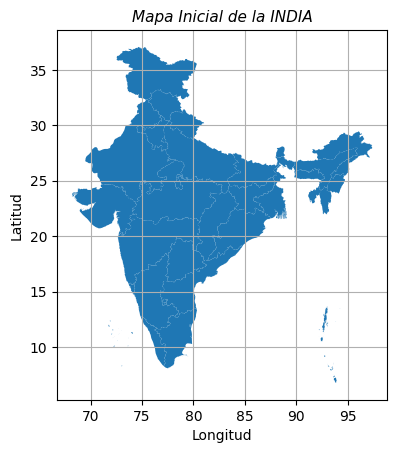

In [51]:
#PINTAMOS UN MAPA INICIAL DE PRUEBA
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [53]:
#instalamos las bibliotecas para hacer el siguiente mapa
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


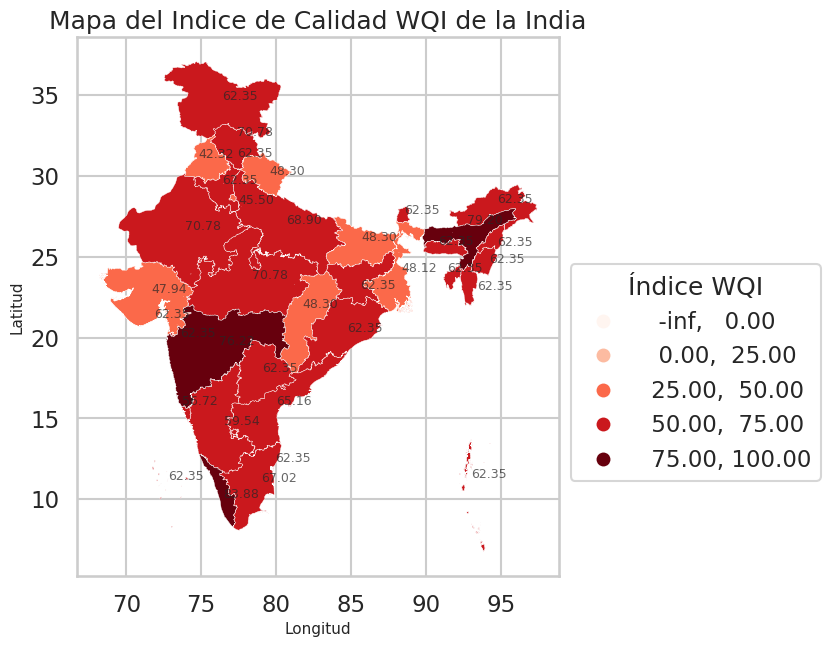

In [54]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

El mapa nos muestra que la mayoria del país tiene valores de WQI comprendidos entre 50 y 75, representados mediante un tono rojo intermedio, lo cual se corresponde con la categoría "Buena". Este hallazgo coincide con lo obtenido en el análisis mediante groupBy, donde el 50.7% de las muestras pertenecían a esa misma categoría dominante.

En el estado ubicado al oeste, representado en un naranja claro y con un WQI de 47.94 presenta las condiciones más deficitarias de todo el mapa. Mientras que un estado del sur con un indice de 83.88 de WQI presenta las mejores condiciones de calidad de agua.

### **Histograma de WQI por Estado**

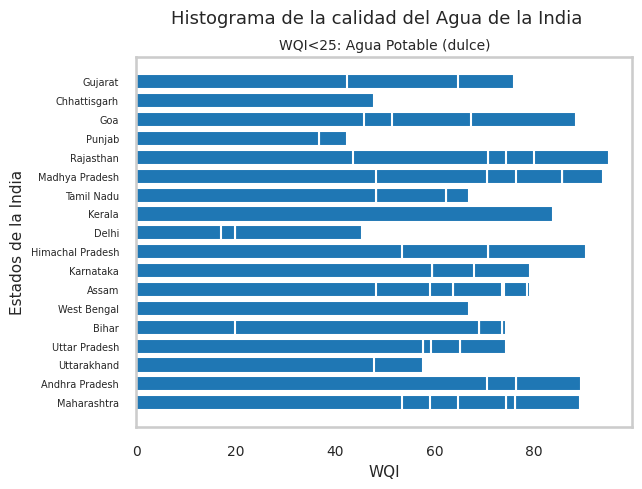

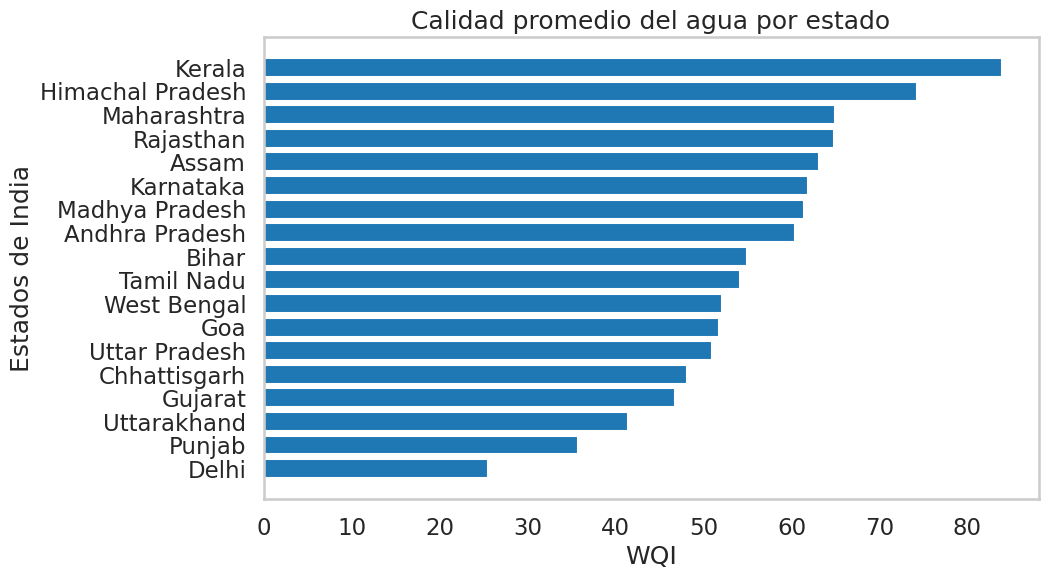

In [65]:
df07.createOrReplaceTempView("df07_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df07_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df07_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()


#Calculamos el promedio y los agrupamos por estado
estado = sparkS.sql("""
SELECT STATE, AVG(WQI) as WQI_promedio
FROM df07_sql
GROUP BY STATE
""")

mapa_prom = estado.toPandas()
mapa_prom = mapa_prom.sort_values("WQI_promedio")

plt.figure(figsize=(10,6))
plt.barh(mapa_prom["STATE"], mapa_prom["WQI_promedio"])
plt.title("Calidad promedio del agua por estado")
plt.xlabel("WQI")
plt.ylabel("Estados de India")
plt.grid()
plt.show()

### Comentarios:
    -Se creó una nueva gráfica la cual calcula el promedio del WQI y lo agrupa al estado al que pertenece, asi se puede interpretar de una manera mas sencilla el nivel promedio de la calidad de agua por cada región de India.

Gracias a las gráficas podemos confirmar que Kerala es el estado que tiene la mejor calidad de agua, ya que obtiene un WQI de más de 80 puntos. Información que se puede confirmar si nos devolvemos al mapa, en el cual era de los pocos cuyo color alcanzaba un rojo oscuro, lo que significaba mejores condiciones del agua. En segundo lugar aparece Himachal Pradesh, con aproximadamente 74 puntos, muy próximo también al umbral de Excelente.
    
En el extremo inferior de la tabla aparecen Delhi, Punjab y Uttarakhand, todos con valores por debajo de 45. Delhi resulta el caso más crítico, con un WQI aproximado de 25, situándose en el límite entre las categorías "Baja" y "Muy Baja".

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [66]:
df07.columns

['CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'OXYGEN',
 'PH',
 'CONDUCTIVITY',
 'GERM',
 'NITROGEN',
 'EXCRETION',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [67]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



Se definen como las variables independientes a las variables que definimos antes como los puntajes de calidad de cada parametro, y la variable dependiente al WQI final y la que debemos predecir. Como se sabe se define el 80% de los datos para el entrenamiento y el 20% restante para las pruebas.
En este caso para la facilidad del codigo solo se usaron las variables antes mencionadas "[qrPH, qrDO, qrCOND, qrBOD, qrNN, qrFecal]" sin embargo, si se quisiera hacer un análisis más exhaustivo se pueden poner las otras variables como temperatura o conductividad, ya que estas últimas pueden tener una repercusión importante en el WQI que queremos predecir.

In [68]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [69]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [70]:
#!pip install keras

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.4 MB 6.0 MB/s            
     |████████████████████████████████| 419 kB 66.5 MB/s            
     |████████████████████████████████| 310 kB 52.8 MB/s            
     |████████████████████████████████| 4.6 MB 64.3 MB/s            
     |████████████████████████████████| 135 kB 27.8 MB/s            
     |████████████████████████████████| 5.0 MB 67.6 MB/s            
     |████████████████████████████████| 87 kB 5.7 MB/s             


In [71]:
#!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
     |█████████████████               | 331.0 MB 179.4 MB/s eta 0:00:02

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



     |████████████████████████████████| 620.4 MB 30 kB/s               
     |████████████████████████████████| 5.5 MB 59.6 MB/s            
     |████████████████████████████████| 323 kB 82.4 MB/s            
     |████████████████████████████████| 71 kB 466 kB/s             
     |████████████████████████████████| 113 kB 71.7 MB/s            
     |████████████████████████████████| 24.5 MB 55.3 MB/s            
     |████████████████████████████████| 6.8 MB 73.3 MB/s            
     |████████████████████████████████| 57 kB 7.7 MB/s             
     |████████████████████████████████| 226 kB 43.1 MB/s            
     |████████████████████████████████| 107 kB 68.8 MB/s            
     |████████████████████████████████| 6.6 MB 47.4 MB/s            


In [77]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense, Input

In [88]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

In [89]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [90]:
modelo01.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

Se implementó una red neuronal secuencial para abordar un problema de regresión, cuyo objetivo es predecir el índice de calidad del agua (WQI) utilizando seis variables de entrada. La arquitectura comienza con una capa densa de 350 neuronas, configurada con `input_dim=6` y activación ReLU, lo que indica que cada observación aporta seis características al modelo.

A continuación se apilan dos capas ocultas adicionales, también densas y con 350 neuronas cada una, manteniendo en ambas la función de activación ReLU. Esta disposición de tres capas ocultas sucesivas con un número elevado de neuronas permite al modelo aprender representaciones complejas y relaciones no lineales entre las variables predictoras y el WQI.

Finalmente, la capa de salida consta de una única neurona con activación lineal, configuración adecuada para predecir un valor continuo como es el caso del índice de calidad del agua.

In [91]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1251.3113 - mse: 1251.3113
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 163.4810 - mse: 163.4810
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 60.8576 - mse: 60.8576
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 25.9687 - mse: 25.9687
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 12.1156 - mse: 12.1156
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.3484 - mse: 7.3484
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.9481 - mse: 3.9481
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.0130 - mse: 2.0130
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3689 - mse: 1.3689
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8827 - mse: 0.8827
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5109 - mse: 0.5109
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3659 - mse: 0.3659
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━

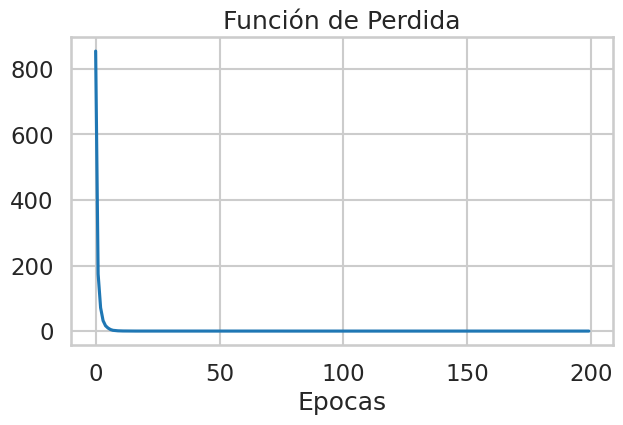

In [94]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Función de Perdida")
plt.xlabel("Epocas")
plt.show()

La evolución de la curva de pérdida revela un descenso durante las primeras iteraciones, sin embargo, luego se estabiliza aproximandose a 0. Este comportamiento evidencia que el modelo logra asimilar adecuadamente las regularidades subyacentes en los datos y alcanza una convergencia sólida, reflejando un entrenamiento exitoso, ya que identifica de manera adecuada los patrones que hay en los datos.

In [95]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [96]:
predModelo01_Test = modelo01.predict(dataTest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [97]:
print(predTrain.shape)
print(predModelo01_Train.shape)

(427, 1)
(427, 1)


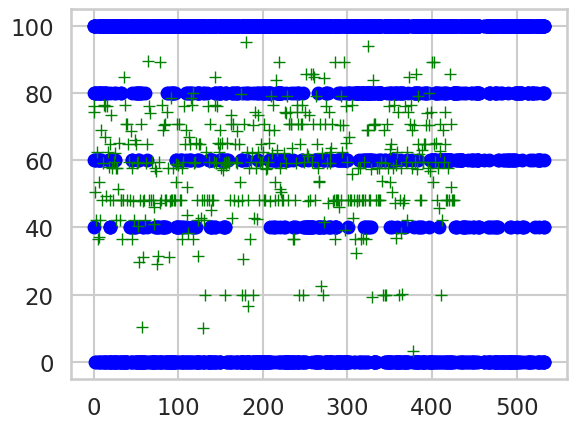

In [98]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()

En esta gráfica se comparan los valores reales del conjunto de entrenamiento con las predicciones generadas por el modelo. Los puntos azules representan los datos reales, mientras que los símbolos verdes corresponden a las predicciones del modelo.
Teniendo esto en cuenta se puede ver lo siguiente:
    -El modelo puede presentar un cierto nivel de ajuste a los datos, ya que las predicciones siguen la tendencia general.
    -Sin embargo, hay desviaciones entre los valores reales y los predichos, lo que sugiere que el modelo no es completamente preciso.
La gráfica permite evaluar visualmente el desempeño del modelo en el conjunto de entrenamiento y sirve como base para decidir si es necesario ajustar el modelo.

## Conclusiones:

En la fase de preparación de datos, se comprobó la importancia de garantizar la consistencia, integridad y calidad de la información. La ausencia de valores nulos y la adecuada selección de variables relevantes permitieron trabajar con un conjunto de datos confiable, lo que impacta directamente en el desempeño de los modelos. Además, el análisis exploratorio facilitó la comprensión de las relaciones entre variables fisicoquímicas del agua, como el oxígeno disuelto, el pH o la demanda bioquímica de oxígeno, evidenciando su influencia en la calidad del recurso hídrico.

La implementación de modelos de Machine Learning utilizando MLlib (y complementariamente Keras) demostró que es posible predecir la calidad del agua con un nivel de precisión significativo. Esto resalta el valor de aplicar técnicas de inteligencia artificial en entornos de datos masivos, donde los métodos tradicionales resultarían insuficientes o poco eficientes. Asimismo, el uso de métricas como accuracy, precision, recall y F1-score permitió evaluar de manera integral el rendimiento de los modelos, evitando interpretaciones sesgadas.